# Final Augmentation Strategy (Presentation Notebook)

This notebook focuses strictly on our **final training augmentation strategy**:
- **Component 1:** `RandomHorizontalFlip(p=0.5)`
- **Component 2 (Strong):** `RandomAffine(...)` + `ColorJitter(...)`

We show (1) a clean side-by-side grid on 3 representative X-rays, (2) a histogram with only **Baseline vs Strong**, and (3) a numeric variety statistic (std-dev increase).

In [15]:
import json
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import transforms

# Reproducibility for consistent visuals
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Locate repo root robustly (works if you run from repo root or from notebooks/)
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'configs').exists() and (REPO_ROOT.parent / 'configs').exists():
    REPO_ROOT = REPO_ROOT.parent

DEFAULT_CONFIG = REPO_ROOT / 'configs' / 'resnet18.json'
CONFIG_PATH = Path(os.getenv('CONFIG_PATH', str(DEFAULT_CONFIG)))
with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config = json.load(f)

TRAIN_CSV = config['train_csv']
IMAGE_BASE_DIR = config['image_base_dir']
IMAGE_SIZE = tuple(config.get('image_size', [256, 256]))
H, W = IMAGE_SIZE

print('Using config:', CONFIG_PATH)
print('TRAIN_CSV:', TRAIN_CSV)
print('IMAGE_BASE_DIR:', IMAGE_BASE_DIR)
print('IMAGE_SIZE:', IMAGE_SIZE)

Using config: /resnick/groups/CS156b/from_central/2026/h3/cs156b/configs/resnet18.json
TRAIN_CSV: /resnick/groups/CS156b/from_central/data/student_labels/train2023.csv
IMAGE_BASE_DIR: /resnick/groups/CS156b/from_central/data/train/
IMAGE_SIZE: (256, 256)


In [16]:
df = pd.read_csv(TRAIN_CSV)
print('Train CSV shape:', df.shape)

def find_path_column(frame: pd.DataFrame) -> str:
    for col in ['Path', 'path', 'image_path', 'Image Index', 'image']:
        if col in frame.columns:
            return col
    raise ValueError('No image path column found in CSV.')

PATH_COL = find_path_column(df)
paths = df[PATH_COL].dropna().astype(str).tolist()
print('PATH_COL:', PATH_COL)
print('Num path entries:', len(paths))

# Path normalization mirrors src/dataset.py (cluster storage layout)
def clean_image_ref(image_ref: str) -> str:
    image_ref = str(image_ref).strip()
    ref = image_ref.replace('CheXpert-v1.0/', '')
    ref = ref.replace('train/', '').replace('valid/', '')
    ref = ref.replace('patient', 'pid')
    return ref

def resolve_image_path(image_ref: str, image_base_dir: str) -> str:
    ref = clean_image_ref(image_ref)
    if os.path.isabs(ref) and os.path.exists(ref):
        return ref
    candidate = os.path.join(image_base_dir, ref)
    if os.path.exists(candidate):
        return candidate
    raise FileNotFoundError(ref)

def collect_resolved(max_items: int = 2000) -> list[str]:
    resolved = []
    for p in paths:
        try:
            resolved.append(resolve_image_path(p, IMAGE_BASE_DIR))
        except Exception:
            continue
        if len(resolved) >= max_items:
            break
    return resolved

resolved_paths = collect_resolved(max_items=2000)
print('Resolved paths (cap=2000):', len(resolved_paths))

def pick_representative(resolved: list[str], n: int = 3) -> list[str]:
    # Prefer a mix of frontal and lateral when available
    basenames = [os.path.basename(p).lower() for p in resolved]
    frontal = [p for p, b in zip(resolved, basenames) if 'frontal' in b]
    lateral = [p for p, b in zip(resolved, basenames) if 'lateral' in b]
    rng = np.random.default_rng(SEED)

    picked = []
    if len(frontal) >= 2:
        idxs = rng.choice(len(frontal), size=2, replace=False)
        picked.extend([frontal[int(i)] for i in idxs])
    elif len(frontal) == 1:
        picked.append(frontal[0])

    if len(lateral) >= 1 and len(picked) < n:
        picked.append(lateral[int(rng.integers(0, len(lateral)))])

    # Fill remaining with random resolved images
    remaining = [p for p in resolved if p not in picked]
    while len(picked) < n and remaining:
        j = int(rng.integers(0, len(remaining)))
        picked.append(remaining.pop(j))

    return picked[:n]

rep_paths = pick_representative(resolved_paths, n=3)
print('Representative images:')
for p in rep_paths:
    print(' -', p)

Train CSV shape: (178158, 16)
PATH_COL: Path
Num path entries: 178158
Resolved paths (cap=2000): 2000
Representative images:
 - /resnick/groups/CS156b/from_central/data/train/pid21256/study36/view1_frontal.jpg
 - /resnick/groups/CS156b/from_central/data/train/pid30737/study14/view1_frontal.jpg
 - /resnick/groups/CS156b/from_central/data/train/pid00539/study1/view2_lateral.jpg


In [21]:
# --- Final augmentation components (only) ---
# Component 1: horizontal flip (train-time probability)
flip_component = transforms.RandomHorizontalFlip(p=0.5)

# Component 2: Strong pipeline core = affine + jitter
def _bilinear_interp():
    try:
        from torchvision.transforms import InterpolationMode
        return InterpolationMode.BILINEAR
    except Exception:
        return Image.BILINEAR

BILINEAR = _bilinear_interp()

def _random_affine(**kwargs):
    # Compatibility wrapper across torchvision versions
    try:
        return transforms.RandomAffine(**kwargs)
    except TypeError:
        kwargs.pop('interpolation', None)
        kwargs.pop('fill', None)
        return transforms.RandomAffine(**kwargs)

affine_component = _random_affine(
    degrees=15,
    translate=(0.10, 0.10),
    scale=(0.90, 1.10),
    interpolation=BILINEAR,
    fill=0,
)
jitter_component = transforms.ColorJitter(brightness=0.25, contrast=0.25)

strong_core = transforms.Compose([
    affine_component,
    jitter_component,
])

# Baseline = current pipeline input representation (RGB tensor in [0,1])
to_rgb = transforms.Lambda(lambda im: im.convert('RGB'))
baseline_tf = transforms.Compose([
    to_rgb,
    transforms.Resize((H, W)),
    transforms.ToTensor(),
])

# Proposed training-time augmentation = Flip + StrongCore + preprocess
strong_tf_train = transforms.Compose([
    to_rgb,
    flip_component,
    strong_core,
    transforms.Resize((H, W)),
    transforms.ToTensor(),
])

# Helper for PIL->tensor post-augmentation
to_tensor_tf = transforms.Compose([transforms.Resize((H, W)), transforms.ToTensor()])

print('Defined only: flip_component (p=0.5) and strong_core (affine + jitter)')

Defined only: flip_component (p=0.5) and strong_core (affine + jitter)


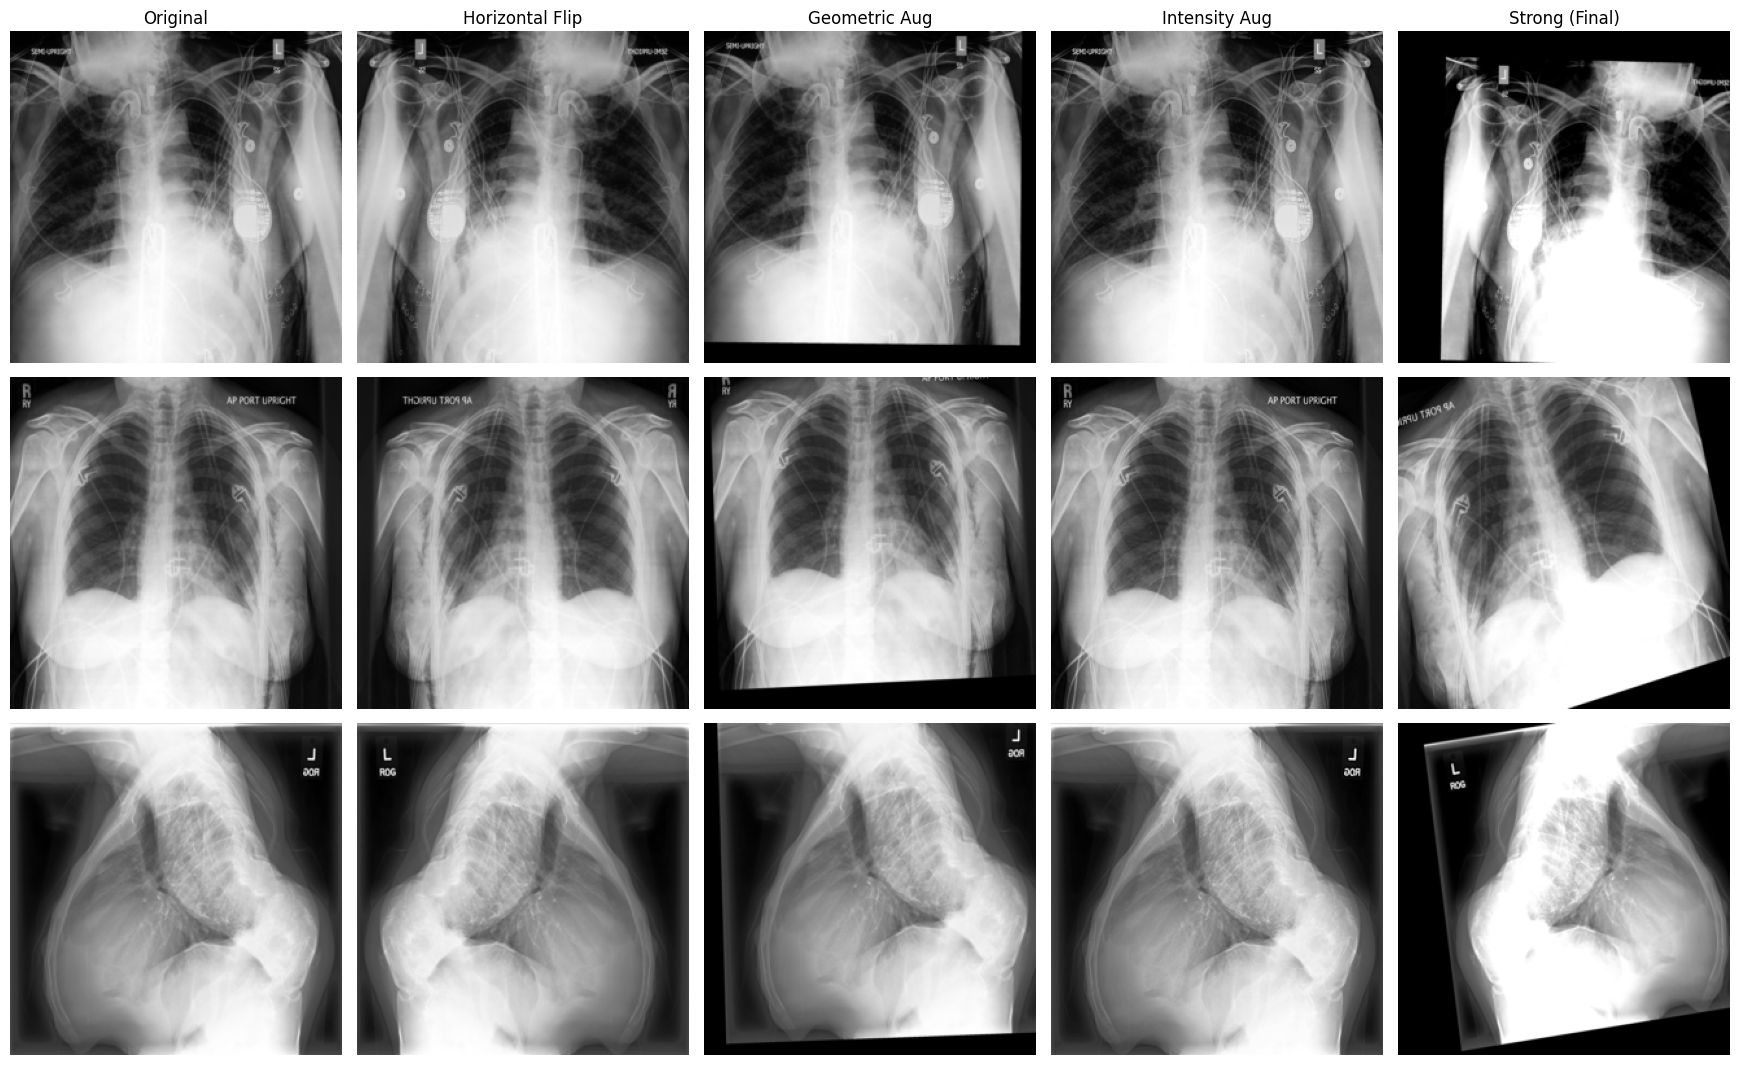

Note: the Flip and Strong columns are forced to flip for visualization. Training uses RandomHorizontalFlip(p=0.5).


In [22]:
# --- Side-by-side grid for 3 representative images ---
# Columns are generated by composing the two components (Flip + StrongCore) for clean presentation.
def load_gray(path: str) -> Image.Image:
    with Image.open(path) as im:
        return im.convert('L')

def tensor_to_gray_uint8(x: torch.Tensor) -> np.ndarray:
    g = x[0].detach().cpu().numpy()
    return (g * 255.0).clip(0, 255).astype(np.uint8)

def pil_hflip(im: Image.Image) -> Image.Image:
    # Always flip for the visualization column (training uses p=0.5)
    return im.transpose(Image.FLIP_LEFT_RIGHT)

cols = ['Original', 'Horizontal Flip', 'Geometric Aug', 'Intensity Aug', 'Strong (Final)']
nrows, ncols = len(rep_paths), len(cols)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.6 * nrows))
if nrows == 1:
    axes = np.array([axes])

for r, p in enumerate(rep_paths):
    img = load_gray(p)
    img_rgb = to_rgb(img)
    img_rgb_flip = to_rgb(pil_hflip(img))

    # Original (baseline preprocessing)
    t_original = baseline_tf(img)

    # Horizontal flip (forced flip just for display)
    t_flip = baseline_tf(pil_hflip(img))

    # Geometric aug = affine only
    t_geo = to_tensor_tf(affine_component(img_rgb))

    # Intensity aug = jitter only
    t_int = to_tensor_tf(jitter_component(img_rgb.resize((H, W))))

    # Strong (final) = flip + affine + jitter (forced flip just for display)
    strong_pil = strong_core(img_rgb_flip)
    t_strong = to_tensor_tf(strong_pil)

    row_tensors = [t_original, t_flip, t_geo, t_int, t_strong]
    for c in range(ncols):
        ax = axes[r, c]
        ax.imshow(tensor_to_gray_uint8(row_tensors[c]), cmap='gray')
        ax.axis('off')
        if r == 0:
            ax.set_title(cols[c])

    axes[r, 0].set_ylabel(os.path.basename(p), rotation=0, labelpad=55, va='center')

plt.tight_layout()
plt.show()

print('Note: the Flip and Strong columns are forced to flip for visualization. Training uses RandomHorizontalFlip(p=0.5).')

Histogram images: 12


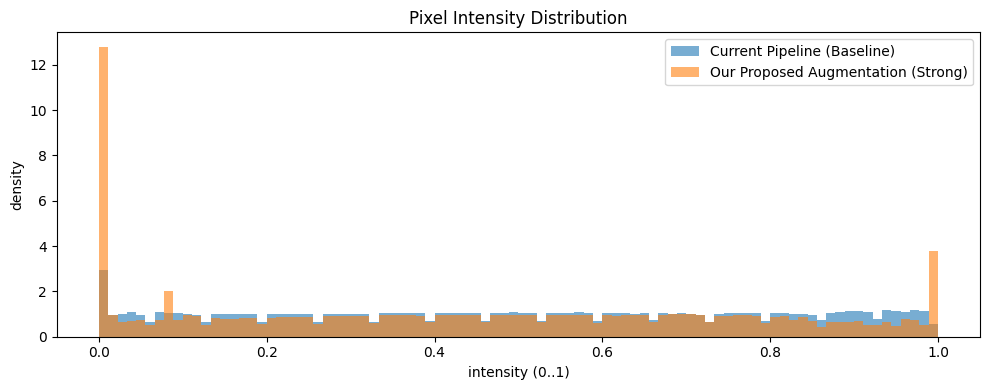

In [23]:
# --- Histogram: only Baseline vs Strong ---
def sample_paths_for_hist(resolved: list[str], n: int = 12) -> list[str]:
    rng = np.random.default_rng(SEED)
    if not resolved:
        return []
    n = min(n, len(resolved))
    idxs = rng.choice(len(resolved), size=n, replace=False)
    return [resolved[int(i)] for i in idxs]

hist_paths = sample_paths_for_hist(resolved_paths, n=12)
print('Histogram images:', len(hist_paths))

def collect_pixels(image_paths: list[str], tf, draws_per_image: int = 1) -> np.ndarray:
    pix = []
    for p in image_paths:
        img = load_gray(p)
        for _ in range(draws_per_image):
            x = tf(img)
            pix.append(x.flatten().numpy())
    if not pix:
        return np.array([], dtype=np.float32)
    return np.concatenate(pix, axis=0)

# Baseline is deterministic; strong is stochastic (we take multiple draws per image)
pix_baseline = collect_pixels(hist_paths, baseline_tf, draws_per_image=1)
pix_strong = collect_pixels(hist_paths, strong_tf_train, draws_per_image=2)

plt.figure(figsize=(10, 4))
plt.hist(pix_baseline, bins=90, alpha=0.60, label='Current Pipeline (Baseline)', density=True)
plt.hist(pix_strong, bins=90, alpha=0.60, label='Our Proposed Augmentation (Strong)', density=True)
plt.title('Pixel Intensity Distribution')
plt.xlabel('intensity (0..1)')
plt.ylabel('density')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# --- Variety statistics: % increase in std-dev from Baseline to Strong ---
baseline_std = float(np.std(pix_baseline))
strong_std = float(np.std(pix_strong))
pct_increase = 100.0 * (strong_std - baseline_std) / max(1e-12, baseline_std)

print(f'Baseline pixel std: {baseline_std:.6f}')
print(f'Strong pixel std:   {strong_std:.6f}')
print(f'Percent increase in std (variety): {pct_increase:.2f}%')

Baseline pixel std: 0.295412
Strong pixel std:   0.319650
Percent increase in std (variety): 8.20%
